# **Winter Road Surface Risk Assessment Based on Dash Camera Images**
### Name: Qiaoxuan Zhang
### Student \#: 3814986

##  Introduction

This project studies winter road-condition risk assessment using vehicle dash camera images. The motivation comes from the high safety risk caused by drivers being unaware of poor road conditions, especially in Canada where winter conditions persist for a long period each year. Instead of estimating detailed physical quantities such as friction coefficient, the goal is to provide a practical and interpretable assessment by classifying road-condition risk into four levels. This avoids overinterpretation while still giving information that is useful for decision making. Such a system could support environment-aware driver assistance and, in the longer term, contribute to safer autonomous driving under winter conditions.

In [43]:
import os
import numpy as np
import pandas as pd
import scipy
import tensorflow as tf
import sklearn
import cv2
import skimage.io
import matplotlib.pyplot as plt
import json

In [ ]:
print(tf.config.list_physical_devices('CPU'))
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
data_path = "/Users/qiaoxuan/Downloads/OneDrive_1_2026-03-25/frames"
im_names = list(filter(lambda x: x.endswith(".jpg"), os.listdir(data_path)))
out_path = "./processed_images"
if not os.path.exists(out_path):
    os.mkdir(out_path)
result_path = "./results"
if not os.path.exists(result_path):
    os.mkdir(result_path)

## Dataset

This dataset comprises 1,592 self-collected dash camera images captured across a variety of road conditions. The data was sourced from a single vehicle and extracted from video clips spanning several distinct trips. To ensure a high-quality, non-redundant collection, similar frames were filtered out using Structural Similarity Index Measure (SSIM) and Mean Square Error (MSE) metrics, followed by a thorough human review process. For the purposes of risk assessment and analysis, each image has been manually annotated with a risk level ranging from 1 to 4.

### Example Data

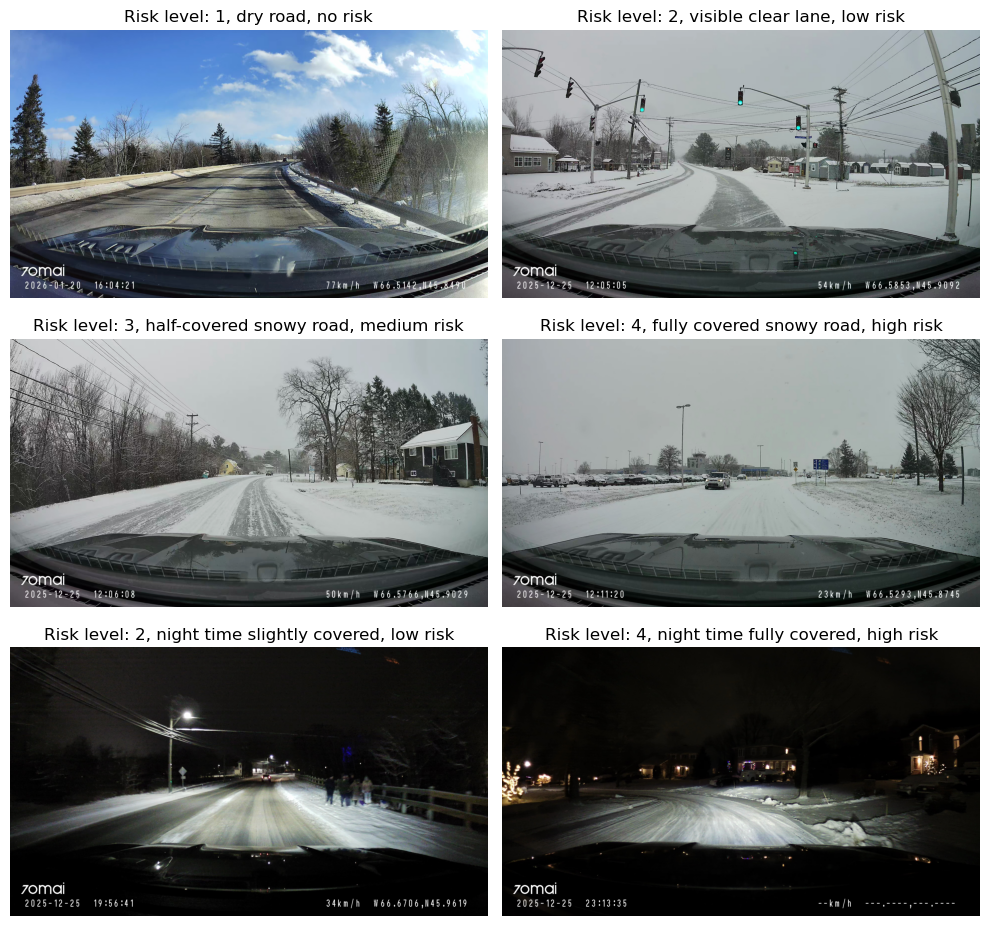

In [ ]:
data_examples = [os.path.join(data_path, im_name) for im_name in [
    "NO20260120-160418-000008F_timestamp_004.00.jpg",
    "NO20251225-120257-000438F_timestamp_128.00.jpg",
    "NO20251225-120557-000439F_timestamp_011.00.jpg",
    "NO20251225-120858-000440F_timestamp_143.07.jpg",
    "night1_timestamp_073.00.jpg",
    "night2_timestamp_028.00.jpg"
]]
descriptions = [
    "dry road, no risk",
    "visible clear lane, low risk",
    "half-covered snowy road, medium risk",
    "fully covered snowy road, high risk",
    "night time slightly covered, low risk",
    "night time fully covered, high risk"
]
risk_labels = [1, 2, 3, 4, 2, 4]
num_examples = len(data_examples)

im_examples = []

n_cols = 2
n_rows = (num_examples + n_cols - 1) // 2
plt.figure(figsize=(10, 0.5 + 3 * n_rows))
for i in range(num_examples):
    im_examples.append(skimage.io.imread(data_examples[i]))
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(im_examples[-1])
    plt.title(f"Risk level: {risk_labels[i]}, {descriptions[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Methods

### Preprocessing

To ensure the data was optimized for risk assessment, the images underwent a structured processing pipeline focused on isolating the road environment.

The workflow began with initial cropping to remove peripheral regions, such as the sky and parts of the vehicle body, that did not contribute to the driving context. Following this, a semantic road mask was generated for every image using a DeepLabV2 model [checkpoint](http://download.tensorflow.org/models/deeplabv3_mnv2_cityscapes_train_2018_02_05.tar.gz) pre-trained on the Cityscapes dataset (available on [https://github.com/tensorflow/models/blob/master/research/deeplab/g3doc/model_zoo.md](https://github.com/tensorflow/models/blob/master/research/deeplab/g3doc/model_zoo.md)).

Based on these masks, three distinct dataset variants were prepared for comparative analysis:

- Cropped Original: Images containing the full cropped scene without any masking.

- Hard-Masked: Images that isolate the road surface by removing all background (non-road) information.

- Soft-Masked: Images that highlight the road area while retaining the background at a reduced intensity to maintain environmental context.

By applying the same experimental methods across all three variants, this processing strategy allows for a clear evaluation of how different levels of visual context influence risk level detection.

### Classification

Two primary modeling approaches were implemented: classical machine learning and deep transfer learning.

#### 1. Machine Learning

The first approach utilized Principal Component Analysis (PCA) for dimensionality reduction to extract the most significant features from the processed images. These features were then fed into two different classifiers for comparison:

(a) Random Forest Classifier

(b) Support Vector Machine (SVM)

#### 2. Transfer Learning

The second approach leveraged pre-trained CNNs to take advantage of established feature extractors. Three architectures were tested:

(a) MobileNetV2

(b) EfficientNetB0

(c) ResNet50

The training process followed a two-stage strategy:

Feature Extraction: Additional pooling and dropout layers were added to the base model and trained while the original pre-trained weights remained frozen.

Fine-Tuning: The top 20% of the layers in the base model were unfrozen and trained to better align the model with the specific nuances of the road risk dataset.

### Evaluation

The performance of these models was evaluated using standard classification metrics, including accuracy, precision, recall, F1-score, and confusion matrices. In addition, although the risk levels are treated as nominal categories during the training and validation process, these models were also evaluated using Mean Absolute Error (MAE) to better capture the ordinal nature of the risk levels.

## Implementation and Results

### Preprocessing

In [ ]:
# helper functions for loading model checkpoint, loading image data,
# preprocessing images, and applying soft masks to images

def load_frozen_graph(pb_path):
    graph = tf.Graph()
    with graph.as_default():
        graph_def = tf.compat.v1.GraphDef()
        with tf.io.gfile.GFile(pb_path, "rb") as f:
            graph_def.ParseFromString(f.read())
        tf.import_graph_def(graph_def, name="")
    return graph


def print_matching_ops(graph, keywords=("image", "input", "semantic", "prediction")):
    print("\nPotentially useful ops:")
    for op in graph.get_operations():
        name = op.name.lower()
        if any(k in name for k in keywords):
            print(op.name)


def resize_and_pad_to_multiple(img_rgb, target_long_side=1024, multiple=32):
    """
    Resize so long side = target_long_side, then pad H/W to a multiple of `multiple`.
    Returns padded image and metadata for undoing the padding.
    """
    h, w = img_rgb.shape[:2]

    scale = target_long_side / max(h, w)
    new_h = max(1, int(round(h * scale)))
    new_w = max(1, int(round(w * scale)))

    img_resized = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    pad_h = (multiple - (new_h % multiple)) % multiple
    pad_w = (multiple - (new_w % multiple)) % multiple

    img_padded = cv2.copyMakeBorder(
        img_resized,
        0, pad_h,
        0, pad_w,
        borderType=cv2.BORDER_CONSTANT,
        value=(0, 0, 0)
    )

    meta = {
        "orig_size": (h, w),
        "resized_size": (new_h, new_w),
        "padded_size": img_padded.shape[:2]
    }
    return img_padded, meta


def crop_back_to_resized(pred_map, meta):
    new_h, new_w = meta["resized_size"]
    return pred_map[:new_h, :new_w]


def resize_pred_to_original(pred_map, meta):
    orig_h, orig_w = meta["orig_size"]
    pred_orig = cv2.resize(
        pred_map.astype(np.uint8),
        (orig_w, orig_h),
        interpolation=cv2.INTER_NEAREST
    )
    return pred_orig


def largest_bottom_connected_component(binary_mask):
    """
    Keep the largest connected component touching the bottom row.
    """
    binary_mask = binary_mask.astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary_mask, connectivity=8
    )

    if num_labels <= 1:
        return binary_mask.astype(np.float32)

    h, w = binary_mask.shape
    bottom_labels = set(labels[h - 1, :].tolist())
    bottom_labels.discard(0)

    if not bottom_labels:
        return binary_mask.astype(np.float32)

    best_label = None
    best_area = -1
    for lab in bottom_labels:
        area = stats[lab, cv2.CC_STAT_AREA]
        if area > best_area:
            best_area = area
            best_label = lab

    kept = (labels == best_label).astype(np.float32)
    return kept


def gaussian_blur_mask(mask01, ksize=21, sigma=7):
    blurred = cv2.GaussianBlur(mask01.astype(np.float32), (ksize, ksize), sigma)
    return np.clip(blurred, 0.0, 1.0)


def make_soft_attention_image(img_rgb, mask01, background_retain=0.3):
    img = img_rgb.astype(np.float32) / 255.0
    weight = background_retain + (1.0 - background_retain) * mask01[..., None]
    out = img * weight
    return np.clip(out, 0.0, 1.0)


def overlay_mask(img_rgb, mask01, alpha=0.45):
    img = img_rgb.astype(np.float32) / 255.0
    red = np.zeros_like(img)
    red[..., 0] = 1.0
    mask3 = mask01[..., None]
    out = (1 - alpha * mask3) * img + (alpha * mask3) * red
    return np.clip(out, 0.0, 1.0)

In [ ]:
# Load the pre-trained checkpoint graph
# Source:
# https://github.com/tensorflow/models/blob/master/research/deeplab/g3doc/model_zoo.md
# Download link:
# http://download.tensorflow.org/models/deeplabv3_mnv2_cityscapes_train_2018_02_05.tar.gz
PB_PATH = "/Users/qiaoxuan/Downloads/deeplabv3_mnv2_cityscapes_train/frozen_inference_graph.pb"
INPUT_TENSOR_NAME = "ImageTensor:0"
OUTPUT_TENSOR_NAME = "SemanticPredictions:0"

graph = load_frozen_graph(PB_PATH)
print("Graph loaded. Number of ops:", len(graph.get_operations()))

print_matching_ops(graph)

inp = graph.get_tensor_by_name(INPUT_TENSOR_NAME)
out = graph.get_tensor_by_name(OUTPUT_TENSOR_NAME)

print("\nInput tensor:", inp, "dtype:", inp.dtype, "shape:", inp.shape)
print("Output tensor:", out, "dtype:", out.dtype, "shape:", out.shape)

Graph loaded. Number of ops: 970

Potentially useful ops:
ImageTensor
MobilenetV2/expanded_conv/input
MobilenetV2/expanded_conv_1/input
MobilenetV2/expanded_conv_2/input
MobilenetV2/expanded_conv_3/input
MobilenetV2/expanded_conv_4/input
MobilenetV2/expanded_conv_5/input
MobilenetV2/expanded_conv_6/input
MobilenetV2/expanded_conv_7/input
MobilenetV2/expanded_conv_8/input
MobilenetV2/expanded_conv_9/input
MobilenetV2/expanded_conv_10/input
MobilenetV2/expanded_conv_11/input
MobilenetV2/expanded_conv_12/input
MobilenetV2/expanded_conv_13/input
MobilenetV2/expanded_conv_14/input
MobilenetV2/expanded_conv_15/input
MobilenetV2/expanded_conv_16/input
image_pooling/weights
image_pooling/weights/read
image_pooling/Conv2D
image_pooling/BatchNorm/gamma
image_pooling/BatchNorm/gamma/read
image_pooling/BatchNorm/beta
image_pooling/BatchNorm/beta/read
image_pooling/BatchNorm/moving_mean
image_pooling/BatchNorm/moving_mean/read
image_pooling/BatchNorm/moving_variance
image_pooling/BatchNorm/moving_v

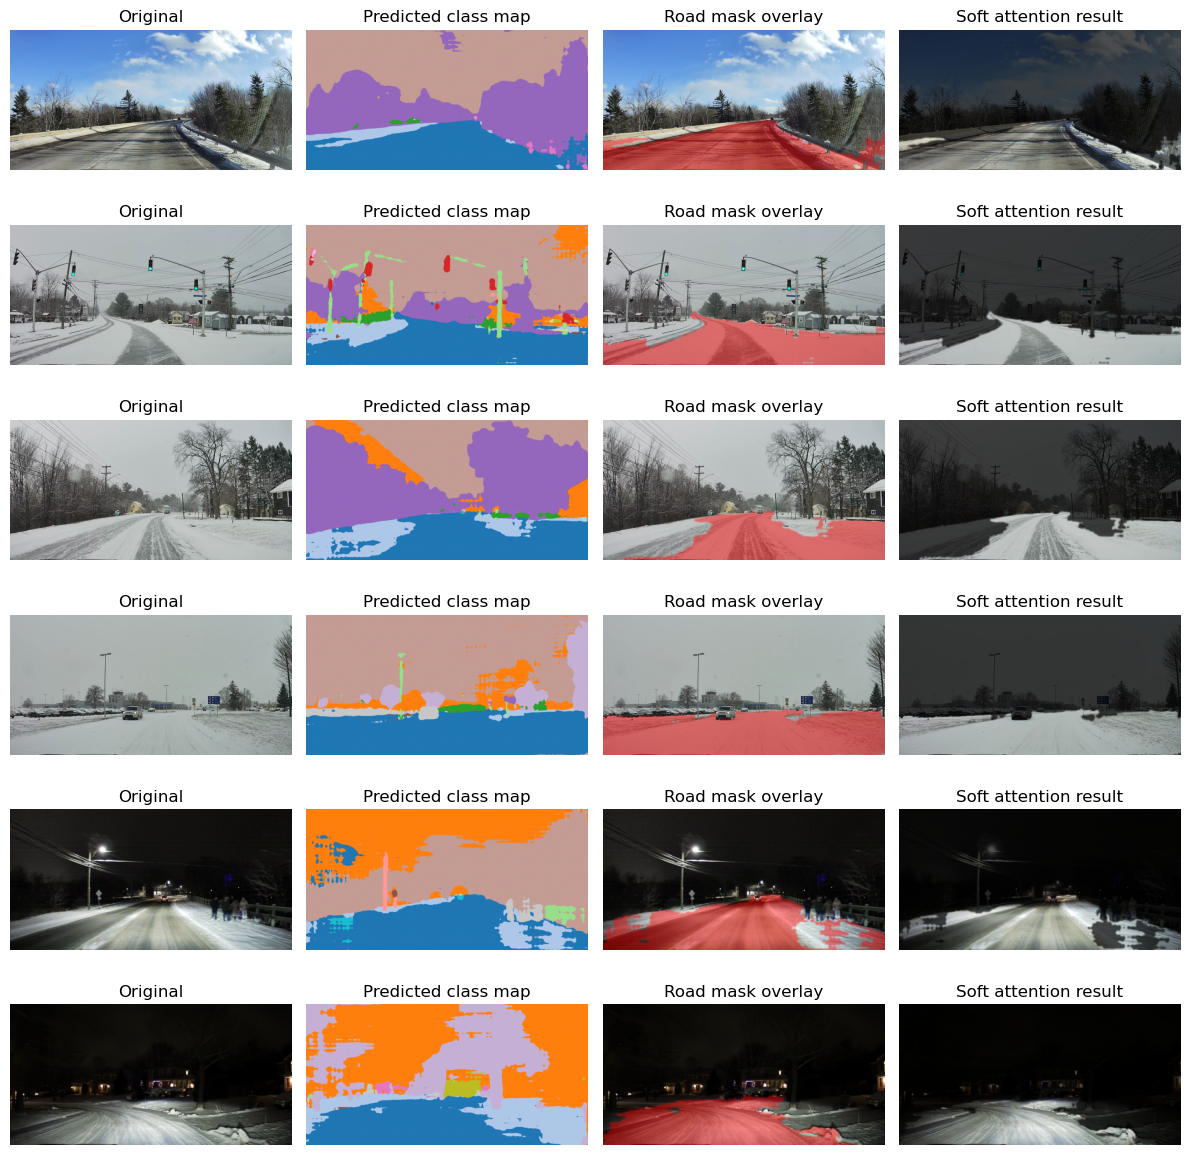

In [ ]:
# For Cityscapes exports, road is often class 0 in the exported prediction map.
ROAD_CLASS_ID = 0
BACKGROUND_RETAIN = 0.3  # soft mask - retain background by the factor
TARGET_LONG_SIDE = 1024
PAD_MULTIPLE = 32

config = tf.compat.v1.ConfigProto(
    device_count={"GPU": 0},
    intra_op_parallelism_threads=1,
    inter_op_parallelism_threads=1,
    allow_soft_placement=True
)

fig, axes = plt.subplots(len(data_examples), 4, figsize=(12, 2*len(data_examples)))

with tf.compat.v1.Session(graph=graph, config=config) as sess:
    for i, im_path in enumerate(data_examples):
        im_bgr = cv2.imread(im_path)
        # convert color and crop the central area, removing random noise on the edge
        im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)[135:1575, 480:3360, ...]

        im_input, meta = resize_and_pad_to_multiple(
            im_rgb,
            target_long_side=TARGET_LONG_SIDE,
            multiple=PAD_MULTIPLE
        )
        im_batch = np.expand_dims(im_input.astype(np.uint8), axis=0)

        # run the inference
        pred = sess.run(out, feed_dict={inp: im_batch})
        pred_map = pred[0]
        pred_map = crop_back_to_resized(pred_map, meta)
        pred_map_orig = resize_pred_to_original(pred_map, meta)

        # build road mask
        road_binary = (pred_map_orig == ROAD_CLASS_ID).astype(np.uint8)
        road_binary = largest_bottom_connected_component(road_binary)
        road_mask = gaussian_blur_mask(road_binary, ksize=21, sigma=7)
        im_att = make_soft_attention_image(
            im_rgb,
            road_mask,
            background_retain=BACKGROUND_RETAIN
        )
        overlay = overlay_mask(im_rgb, road_mask, alpha=0.45)

        # plot results
        axes[i, 0].imshow(im_rgb)
        axes[i, 0].set_title("Cropped")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(pred_map_orig, cmap="tab20")
        axes[i, 1].set_title("Predicted class map")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Road mask overlay")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(im_att)
        axes[i, 3].set_title("Soft attention result")
        axes[i, 3].axis("off")

plt.tight_layout()
plt.show()

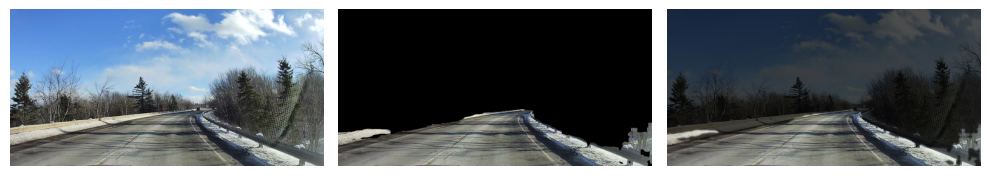

In [ ]:
plt.figure(figsize=(10, 3))
for i, im_type in enumerate(["cropped", "masked", "soft_masked"]):
    im_bgr = cv2.imread(os.path.join(out_path, im_type, f"NO20260120-160418-000008F_timestamp_004.00_{im_type}.jpg"))
    im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
    plt.subplot(1,3,i+1)
    plt.imshow(im_rgb)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
suffices = ["cropped", "road_mask", "soft_masked", "masked"]
processed_im_names = list(filter(lambda x: x.endswith(".jpg"),
                                 os.listdir(os.path.join(out_path, suffices[0]))))

# process all the images
count = 0
with tf.compat.v1.Session(graph=graph, config=config) as sess:
    for i, im_name in enumerate(im_names):
        if not f"{im_name[:-4]}_{suffices[0]}.jpg" in processed_im_names:
            im_path = os.path.join(data_path, im_name)
            im_bgr = cv2.imread(im_path)
            # convert color and crop the central area, removing random noise on the edge
            im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)[135:1575, 480:3360, ...]

            im_input, meta = resize_and_pad_to_multiple(
                im_rgb,
                target_long_side=TARGET_LONG_SIDE,
                multiple=PAD_MULTIPLE
            )
            im_batch = np.expand_dims(im_input.astype(np.uint8), axis=0)

            # run the inference
            pred = sess.run(out, feed_dict={inp: im_batch})
            pred_map = pred[0]
            pred_map = crop_back_to_resized(pred_map, meta)
            pred_map_orig = resize_pred_to_original(pred_map, meta)

            # build road mask
            road_binary = (pred_map_orig == ROAD_CLASS_ID).astype(np.uint8)
            road_binary = largest_bottom_connected_component(road_binary)
            road_mask = gaussian_blur_mask(road_binary, ksize=21, sigma=7)
            im_att = make_soft_attention_image(
                im_rgb,
                road_mask,
                background_retain=BACKGROUND_RETAIN
            )
            im_masked = im_rgb.copy()
            im_masked[np.where(road_mask == 0)] = 0
            overlay = overlay_mask(im_rgb, road_mask, alpha=0.45)

            # save images
            for im, suffix in zip([im_rgb, road_mask * 255, im_att * 255, im_masked], suffices):
                cv2.imwrite(os.path.join(out_path, suffix, f"{im_name[:-4]}_{suffix}.jpg"),
                            cv2.cvtColor(im, cv2.COLOR_RGB2BGR))
        count += 1
        if count % 100 == 0:
            print(f"Processed {count} images")


Processed 100 images
Processed 200 images
Processed 300 images
Processed 400 images
Processed 500 images
Processed 600 images
Processed 700 images
Processed 800 images
Processed 900 images
Processed 1000 images
Processed 1100 images
Processed 1200 images
Processed 1300 images
Processed 1400 images
Processed 1500 images


### Classification

In [ ]:
# helper functions

def load_im_and_labels(data_type, gray=True, resize_factor=6, im_size=None, flatten=True):
    suffices = ["cropped", "soft_masked", "masked"]
    suffix_index = (image_data_type == "original") * 0 + \
                   (image_data_type == "soft_masked") * 1 + \
                   (image_data_type == "masked") * 2
    image_data_path = os.path.join(out_path, suffices[suffix_index])

    image_label_path = "/Users/qiaoxuan/Downloads/OneDrive_1_2026-03-25/frames/label.json"
    with open(image_label_path, "r") as f:
        image_labels = json.load(f)

    X = []
    y = []
    for im_name in os.listdir(image_data_path):
        if im_name.endswith(".jpg"):
            if gray:
                im = cv2.imread(os.path.join(image_data_path, im_name), cv2.IMREAD_GRAYSCALE)
            else:
                im = cv2.imread(os.path.join(image_data_path, im_name))
                im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
            if im_size is None:
                im = cv2.resize(im, (im.shape[1] // resize_factor, im.shape[0] // resize_factor))
            else:
                im = cv2.resize(im, im_size)
            if flatten:
                X.append(im.ravel() / 255)
            else:
                X.append(im.astype(np.float32))
            y.append(image_labels[im_name[:im_name.rfind(f"_{suffices[suffix_index]}")]])
    return np.array(X), np.array(y)

def prepare_train_test_data(X, y, test_size=0.4, val_size=0, standardize=True, pca_components=None):
    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
        X, y, test_size=test_size, random_state=42)
    if val_size > 0:
        X_train, X_val, y_train, y_val = sklearn.model_selection.train_test_split(
            X_train, y_train, test_size=val_size/(1-test_size), random_state=42)
    else:
        X_val, y_val = None, None

    if standardize:
        scalar = sklearn.preprocessing.StandardScaler()
        X_train = scalar.fit_transform(X_train)
        X_test = scalar.transform(X_test)

    if pca_components is not None:
        pca = sklearn.decomposition.PCA(n_components=pca_components,
                                        svd_solver="randomized", whiten=True)
        pca = pca.fit(X_train)
        X_train = pca.fit_transform(X_train)
        X_test = pca.transform(X_test)
    return X_train, X_val, X_test, y_train, y_val, y_test

def display_metrics(clf, X_test, y_test, y_pred):
    print(sklearn.metrics.classification_report(y_test, y_pred))

    sklearn.metrics.ConfusionMatrixDisplay.from_estimator(
        clf, X_test, y_test,
        display_labels=['1', '2', '3', '4'], xticks_rotation="vertical"
    )
    plt.tight_layout()
    plt.show()

#### 1. Machine Learning Methods

##### 1. (a) PCA + Random Forest

###### (i) Using Original Images

In [ ]:
image_data_type = "original"  # original, masked, or soft_masked

X, y = load_im_and_labels(image_data_type, gray=True, resize_factor=6, flatten=True)
X_train, _, X_test, y_train, _, y_test = prepare_train_test_data(
    X, y, test_size=0.4, val_size=0, standardize=True, pca_components=150
)

RandomForestClassifier(max_depth=10, n_estimators=500)
              precision    recall  f1-score   support

           1       0.77      0.71      0.74       246
           2       0.52      0.75      0.61       221
           3       0.68      0.39      0.49       118
           4       0.71      0.33      0.45        52

    accuracy                           0.63       637
   macro avg       0.67      0.54      0.57       637
weighted avg       0.66      0.63      0.63       637



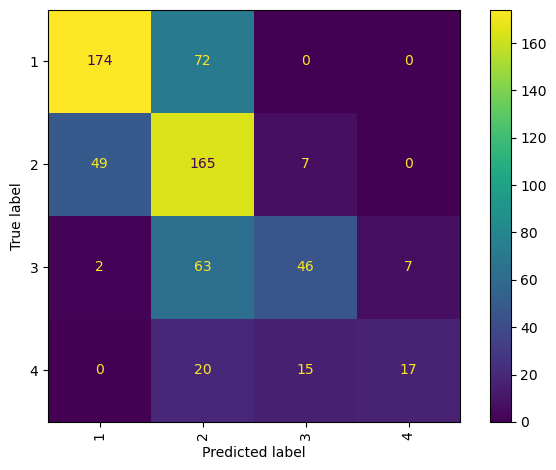

In [ ]:
params_grid = {
    "n_estimators": [10, 100, 500, 1000],
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 6, 10]
}
rf = sklearn.ensemble.RandomForestClassifier()
clf = sklearn.model_selection.GridSearchCV(rf, params_grid, cv=5, n_jobs=-1)
clf.fit(X_train, y_train)
print(clf.best_estimator_)
y_pred = clf.predict(X_test)

display_metrics(clf, X_test, y_test, y_pred)

In [44]:
print(f"MAE: {(72+49+7+63+7+15+(2+20)*2) / (246+221+118+52)}")

MAE: 0.40345368916797486


###### (ii) Using Masked Images

RandomForestClassifier(criterion='entropy', max_depth=10, n_estimators=1000)
              precision    recall  f1-score   support

           1       0.62      0.83      0.71       223
           2       0.58      0.56      0.57       254
           3       0.63      0.41      0.49       113
           4       0.84      0.34      0.48        47

    accuracy                           0.61       637
   macro avg       0.67      0.53      0.56       637
weighted avg       0.62      0.61      0.60       637



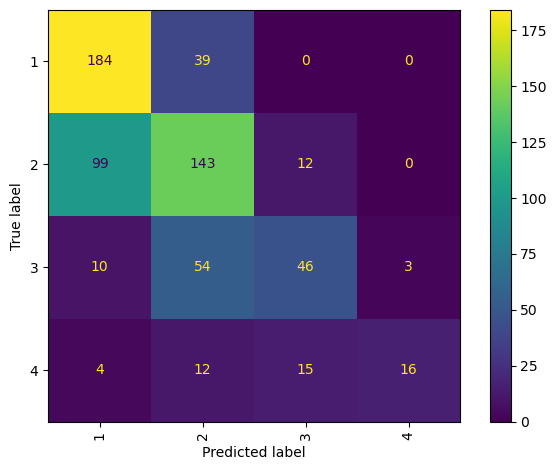

In [ ]:
image_data_type = "masked"  # original, masked, or soft_masked

X, y = load_im_and_labels(image_data_type, gray=True, resize_factor=6, flatten=True)
X_train, _, X_test, y_train, _, y_test = prepare_train_test_data(
    X, y, test_size=0.4, val_size=0, standardize=True, pca_components=150
)

params_grid = {
    "n_estimators": [10, 100, 500, 1000],
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 6, 10]
}
rf = sklearn.ensemble.RandomForestClassifier()
clf = sklearn.model_selection.GridSearchCV(rf, params_grid, cv=5, n_jobs=-1)
clf.fit(X_train, y_train)
print(clf.best_estimator_)
y_pred = clf.predict(X_test)

display_metrics(clf, X_test, y_test, y_pred)

In [45]:
print(f"MAE: {(39+99+12+54+3+15+(10+12)*2+4*3) / (223+254+113+47)}")

MAE: 0.4364207221350079


###### (iii) Using Soft-Masked Images

RandomForestClassifier(max_depth=10, n_estimators=500)
              precision    recall  f1-score   support

           1       0.65      0.86      0.74       230
           2       0.55      0.56      0.55       243
           3       0.67      0.37      0.48       115
           4       0.71      0.35      0.47        49

    accuracy                           0.62       637
   macro avg       0.65      0.53      0.56       637
weighted avg       0.62      0.62      0.60       637



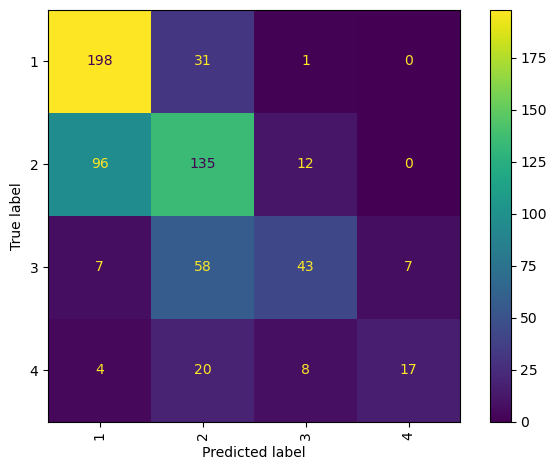

In [ ]:
image_data_type = "soft_masked"  # original, masked, or soft_masked

X, y = load_im_and_labels(image_data_type, gray=True, resize_factor=6, flatten=True)
X_train, _, X_test, y_train, _, y_test = prepare_train_test_data(
    X, y, test_size=0.4, val_size=0, standardize=True, pca_components=150
)

params_grid = {
    "n_estimators": [10, 100, 500, 1000],
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 6, 10]
}
rf = sklearn.ensemble.RandomForestClassifier()
clf = sklearn.model_selection.GridSearchCV(rf, params_grid, cv=5, n_jobs=-1)
clf.fit(X_train, y_train)
print(clf.best_estimator_)
y_pred = clf.predict(X_test)

display_metrics(clf, X_test, y_test, y_pred)

In [46]:
print(f"MAE: {(31+12+7+96+58+8+(1+7+20)*2+4*3) / (230+243+115+49)}")

MAE: 0.43956043956043955


##### 1. (b) PCA + SVM

###### (i) Using Original Images

SVC(C=100, class_weight='balanced', gamma=0.0001)
              precision    recall  f1-score   support

           1       0.75      0.72      0.74       246
           2       0.60      0.50      0.55       221
           3       0.51      0.64      0.57       118
           4       0.59      0.79      0.67        52

    accuracy                           0.64       637
   macro avg       0.61      0.66      0.63       637
weighted avg       0.64      0.64      0.63       637



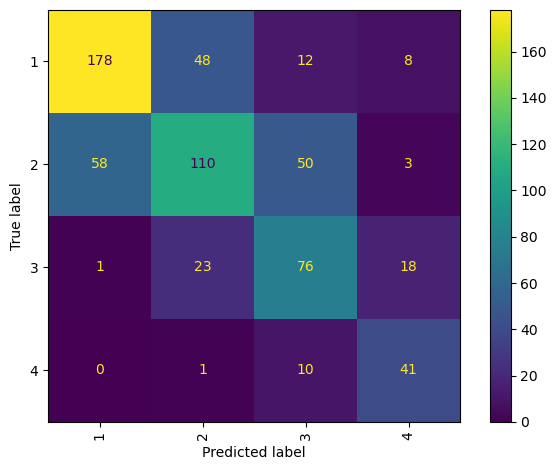

In [ ]:
image_data_type = "original"  # original, masked, or soft_masked

X, y = load_im_and_labels(image_data_type, gray=True, resize_factor=6, flatten=True)
X_train, _, X_test, y_train, _, y_test = prepare_train_test_data(
    X, y, test_size=0.4, val_size=0, standardize=True, pca_components=150
)

params_grid = {
    "C": [1, 100, 10000],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1]
}
clf = sklearn.model_selection.RandomizedSearchCV(
    sklearn.svm.SVC(kernel="rbf", class_weight="balanced"),
    params_grid,
    n_iter=10
)
clf = clf.fit(X_train, y_train)
print(clf.best_estimator_)
y_pred = clf.predict(X_test)
display_metrics(clf, X_test, y_test, y_pred)

In [47]:
print(f"MAE: {(48+50+18+58+23+10+(12+3+1+1)*2+8*3) / (246+221+118+52)}")

MAE: 0.41601255886970173


###### (ii) Using Masked Images

SVC(C=1, class_weight='balanced', gamma=0.001)
              precision    recall  f1-score   support

           1       0.59      0.83      0.69       223
           2       0.61      0.39      0.48       254
           3       0.57      0.48      0.52       113
           4       0.54      0.79      0.64        47

    accuracy                           0.59       637
   macro avg       0.58      0.62      0.58       637
weighted avg       0.59      0.59      0.57       637



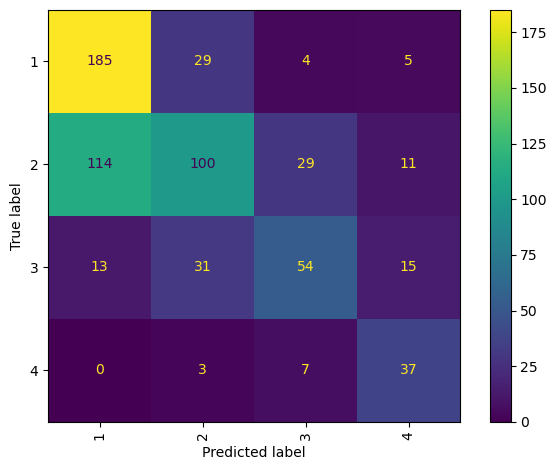

In [ ]:
image_data_type = "masked"  # original, masked, or soft_masked

X, y = load_im_and_labels(image_data_type, gray=True, resize_factor=6, flatten=True)
X_train, _, X_test, y_train, _, y_test = prepare_train_test_data(
    X, y, test_size=0.4, val_size=0, standardize=True, pca_components=150
)

params_grid = {
    "C": [1, 100, 10000],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1]
}
clf = sklearn.model_selection.RandomizedSearchCV(
    sklearn.svm.SVC(kernel="rbf", class_weight="balanced"),
    params_grid,
    n_iter=10
)
clf = clf.fit(X_train, y_train)
print(clf.best_estimator_)
y_pred = clf.predict(X_test)
display_metrics(clf, X_test, y_test, y_pred)

In [48]:
print(f"MAE: {(29+29+15+114+31+7+(4+11+13+3)*2+5*3) / (223+254+113+47)}")

MAE: 0.4740973312401884


###### (iii) Using Soft-Masked Images

SVC(C=1, class_weight='balanced', gamma=0.001)
              precision    recall  f1-score   support

           1       0.71      0.75      0.73       230
           2       0.62      0.52      0.57       243
           3       0.52      0.56      0.54       115
           4       0.58      0.80      0.67        49

    accuracy                           0.63       637
   macro avg       0.61      0.66      0.63       637
weighted avg       0.63      0.63      0.63       637



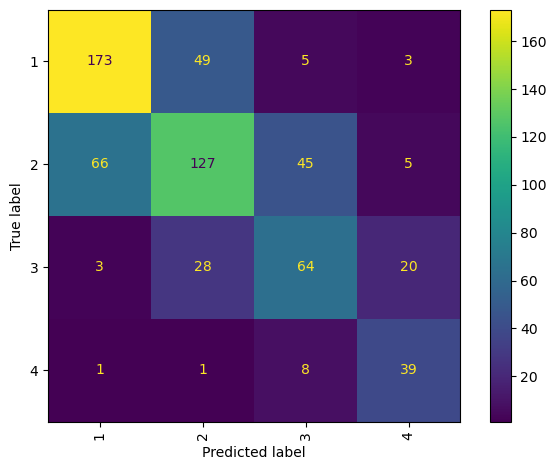

In [ ]:
image_data_type = "soft_masked"  # original, masked, or soft_masked

X, y = load_im_and_labels(image_data_type, gray=True, resize_factor=6, flatten=True)
X_train, _, X_test, y_train, _, y_test = prepare_train_test_data(
    X, y, test_size=0.4, val_size=0, standardize=True, pca_components=150
)

params_grid = {
    "C": [1, 100, 10000],
    "gamma": [1e-4, 1e-3, 1e-2, 0.1]
}
clf = sklearn.model_selection.RandomizedSearchCV(
    sklearn.svm.SVC(kernel="rbf", class_weight="balanced"),
    params_grid,
    n_iter=10
)
clf = clf.fit(X_train, y_train)
print(clf.best_estimator_)
y_pred = clf.predict(X_test)
display_metrics(clf, X_test, y_test, y_pred)

In [49]:
print(f"MAE: {(49+45+20+66+28+8+(5+5+3+1)*2+4*3) / (230+243+115+49)}")

MAE: 0.40188383045525905


#### 2. Transfer learning

In [ ]:
image_data_type = "soft_masked"  # original, masked, or soft_masked

X, y = load_im_and_labels(image_data_type, gray=False, im_size=(224, 224), flatten=False)
y -= 1
X_train, X_val, X_test, y_train, y_val, y_test = prepare_train_test_data(
    X, y, test_size=0.2, val_size=0.2, standardize=False, pca_components=None
)

##### 2. (a) MobileNetV2

In [ ]:
im_shape = X.shape[1:]

base = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=im_shape,
)
base.trainable = False

inputs = tf.keras.Input(shape=im_shape)
x = tf.keras.applications.mobilenet.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(result_path, "mobilenet.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

r1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=callbacks
)

base.trainable = True
for layer in base.layers[:int(len(base.layers) * 0.8)]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

r2 = model.fit(X_train, y_train, validation_data=(X_val, y_val),
               epochs=10, callbacks=callbacks)

best_model = tf.keras.models.load_model(os.path.join(result_path, "mobilenet.keras"))

test_loss, test_acc = model.evaluate(X_test, y_test)
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

f1 = sklearn.metrics.f1_score(y_test, y_pred, average="macro")
mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 231ms/step - accuracy: 0.4403 - loss: 1.3102 - val_accuracy: 0.5392 - val_loss: 1.0488 - learning_rate: 0.0010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.5671 - loss: 1.0060 - val_accuracy: 0.6050 - val_loss: 0.9274 - learning_rate: 0.0010
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.5975 - loss: 0.9564 - val_accuracy: 0.6426 - val_loss: 0.8917 - learning_rate: 0.0010
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.6405 - loss: 0.8477 - val_accuracy: 0.6238 - val_loss: 0.9292 - learning_rate: 0.0010
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.6300 - loss: 0.8534 - val_accuracy: 0.6050 - val_loss: 0.8781 - learning_rate: 0.0010
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.6782 - loss: 0.7769 - val_accuracy: 0.6489 - val_loss: 0.8453 - learning_rate: 0.0010
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.6688 - loss: 0.7655 - 

F1-score: 0.5992067835546097
MAE: 0.3793103448275862


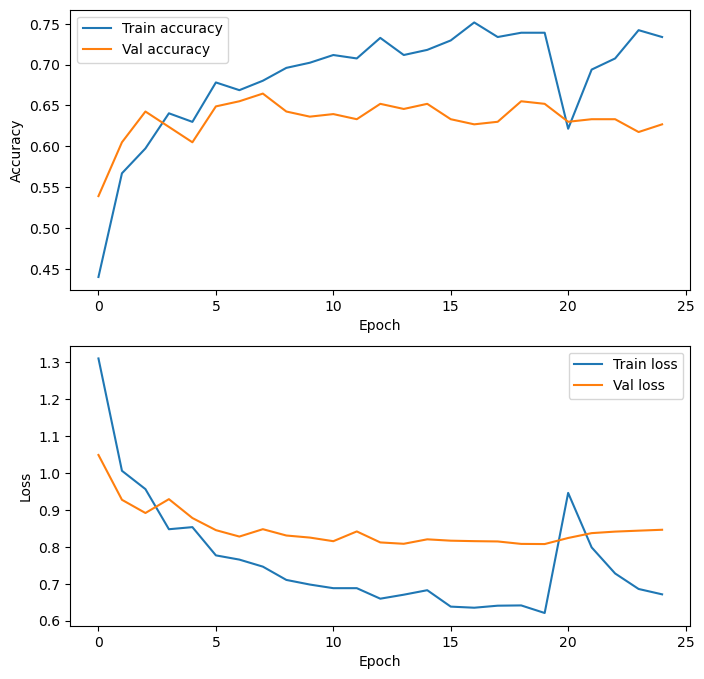

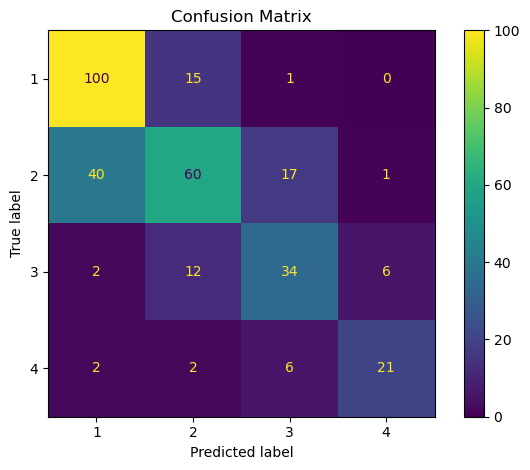

In [50]:
print(f"F1-score: {f1}")
print(f"MAE: {mae}")

epoch_summary = {k: r1.history[k] + (r2.history.get(k) or []) for k in r1.history}

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epoch_summary["accuracy"], label="Train accuracy")
plt.plot(epoch_summary["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epoch_summary["loss"], label="Train loss")
plt.plot(epoch_summary["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                              display_labels=[1, 2, 3, 4])
disp.plot(cmap="viridis", values_format="d")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

##### 2. (b) EfficientNetB0

In [ ]:
im_shape = X.shape[1:]

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=im_shape,
)
base.trainable = False

inputs = tf.keras.Input(shape=im_shape)
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 288, 288, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 9, 9, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(result_path, "checkpoint.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

r1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 384ms/step - accuracy: 0.4455 - loss: 1.1713 - val_accuracy: 0.5580 - val_loss: 0.9963 - learning_rate: 0.0010
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 338ms/step - accuracy: 0.6153 - loss: 0.9346 - val_accuracy: 0.6176 - val_loss: 0.9022 - learning_rate: 0.0010
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 335ms/step - accuracy: 0.6342 - loss: 0.8529 - val_accuracy: 0.6426 - val_loss: 0.8581 - learning_rate: 0.0010
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 335ms/step - accuracy: 0.6646 - loss: 0.8112 - val_accuracy: 0.6301 - val_loss: 0.8450 - learning_rate: 0.0010
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 341ms/step - accuracy: 0.6960 - loss: 0.7559 - val_accuracy: 0.6708 - val_loss: 0.8276 - learning_rate: 0.0010
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 343ms/step - accuracy: 0.6971 - loss: 0.7468 - val_accuracy: 0.6552 - val_loss: 0.8258 - learning_rate: 0.0010
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 364ms/step - accuracy: 0.7034 - loss: 0.

In [ ]:
base.trainable = True
for layer in base.layers[:int(len(base.layers) * 0.8)]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

r2 = model.fit(X_train, y_train, validation_data=(X_val, y_val),
               epochs=10, callbacks=callbacks)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 459ms/step - accuracy: 0.6258 - loss: 0.9328 - val_accuracy: 0.6897 - val_loss: 0.7979 - learning_rate: 1.0000e-05
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 426ms/step - accuracy: 0.6604 - loss: 0.8925 - val_accuracy: 0.6959 - val_loss: 0.8086 - learning_rate: 1.0000e-05
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6890 - loss: 0.8267
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 428ms/step - accuracy: 0.6771 - loss: 0.8430 - val_accuracy: 0.6834 - val_loss: 0.8146 - learning_rate: 1.0000e-05
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 432ms/step - accuracy: 0.6929 - loss: 0.8004 - val_accuracy: 0.6834 - val_loss: 0.8169 - learning_rate: 5.0000e-06
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.6538 - loss: 0.8329
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 430ms/step - accuracy: 0.692

In [ ]:
best_model = tf.keras.models.load_model(os.path.join(result_path, "checkpoint.keras"))

test_loss, test_acc = model.evaluate(X_test, y_test)
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

f1 = sklearn.metrics.f1_score(y_test, y_pred, average="macro")
mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step - accuracy: 0.6740 - loss: 0.8106
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step


In [ ]:
print("F1-score")
print(f1)
print("MAE")
print(mae)
print("Confusion matrix")
print(cm)

F1-score
0.6669870445202059
MAE
0.3573667711598746
Confusion matrix
[[100  15   1   0]
 [ 40  60  17   1]
 [  2  12  34   6]
 [  2   2   6  21]]


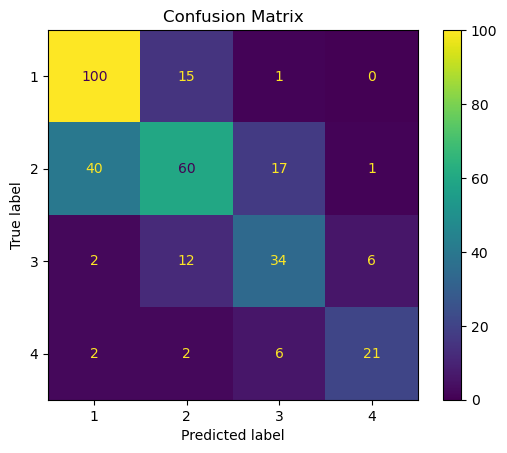

In [42]:
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                              display_labels=[1, 2, 3, 4])
disp.plot(cmap="viridis", values_format="d")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

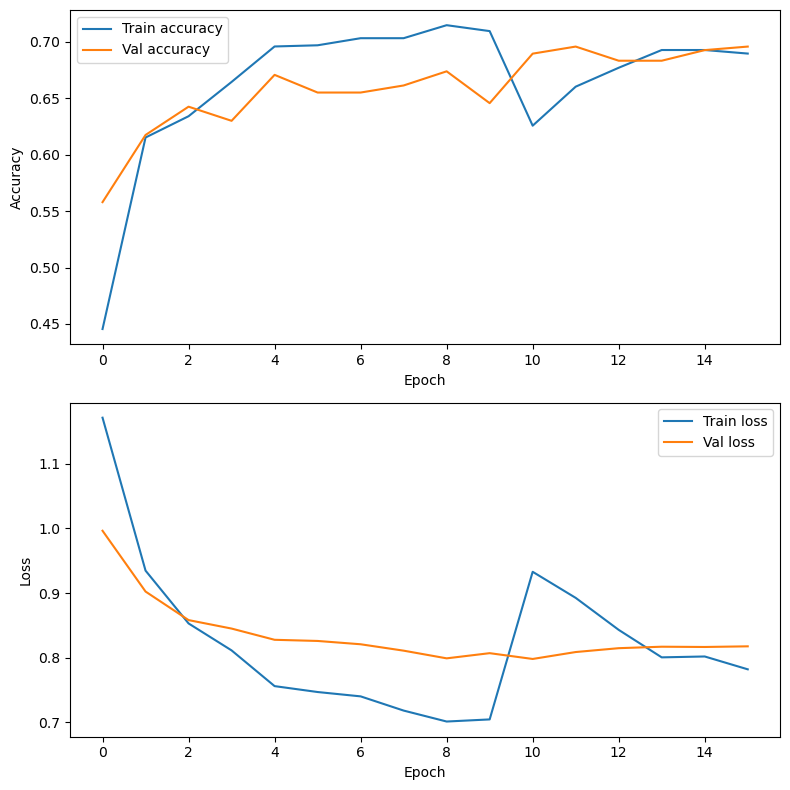

In [ ]:
epoch_summary = {k: r1.history[k] + (r2.history.get(k) or []) for k in r1.history}

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epoch_summary["accuracy"], label="Train accuracy")
plt.plot(epoch_summary["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epoch_summary["loss"], label="Train loss")
plt.plot(epoch_summary["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

##### 2. (c) ResNet50

In [ ]:
im_shape = X.shape[1:]

base = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=im_shape,
)
base.trainable = False

inputs = tf.keras.Input(shape=im_shape)
x = tf.keras.applications.resnet.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(4, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │      8,196 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(result_path, "checkpoint.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

r1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 824ms/step - accuracy: 0.4109 - loss: 1.5996 - val_accuracy: 0.5705 - val_loss: 1.0201 - learning_rate: 0.0010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 769ms/step - accuracy: 0.5629 - loss: 1.1218 - val_accuracy: 0.6301 - val_loss: 0.8467 - learning_rate: 0.0010
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 763ms/step - accuracy: 0.6017 - loss: 0.9614 - val_accuracy: 0.6238 - val_loss: 0.9365 - learning_rate: 0.0010
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 766ms/step - accuracy: 0.6321 - loss: 0.9131 - val_accuracy: 0.6771 - val_loss: 0.7922 - learning_rate: 0.0010
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 772ms/step - accuracy: 0.6530 - loss: 0.8245 - val_accuracy: 0.6834 - val_loss: 0.7707 - learning_rate: 0.0010
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 768ms/step - accuracy: 0.6719 - loss: 0.7784 - val_accuracy: 0.6865 - val_loss: 0.7611 - learning_rate: 0.0010
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 771ms/step - accuracy: 0.6929 - loss: 0.

In [ ]:
base.trainable = True
for layer in base.layers[:int(len(base.layers) * 0.8)]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

r2 = model.fit(X_train, y_train,
               validation_data=(X_val, y_val),
               epochs=20,
               callbacks=callbacks)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6730 - loss: 0.7759 - val_accuracy: 0.6458 - val_loss: 0.7708 - learning_rate: 1.0000e-05
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - accuracy: 0.8033 - loss: 0.5122
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.7799 - loss: 0.5351 - val_accuracy: 0.6740 - val_loss: 0.7923 - learning_rate: 1.0000e-05
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8386 - loss: 0.4585 - val_accuracy: 0.6928 - val_loss: 0.7831 - learning_rate: 5.0000e-06
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 929ms/step - accuracy: 0.8551 - loss: 0.4030
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8501 - loss: 0.4073 - val_accuracy: 0.7022 - val_loss: 0.7801 - learning_rate: 5.0000e-06
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8805 - loss: 0.342

In [ ]:
best_model = tf.keras.models.load_model(os.path.join(result_path, "checkpoint.keras"))

test_loss, test_acc = model.evaluate(X_test, y_test)
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

f1 = sklearn.metrics.f1_score(y_test, y_pred, average="macro")
mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 578ms/step - accuracy: 0.6520 - loss: 0.8898
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 573ms/step


In [ ]:
print("F1-score")
print(f1)
print("MAE")
print(mae)
print("Confusion matrix")
print(cm)

F1-score
0.610406051009291
MAE
0.3730407523510972
Confusion matrix
[[84 31  1  0]
 [25 77 16  0]
 [ 1 15 37  1]
 [ 1  4 16 10]]


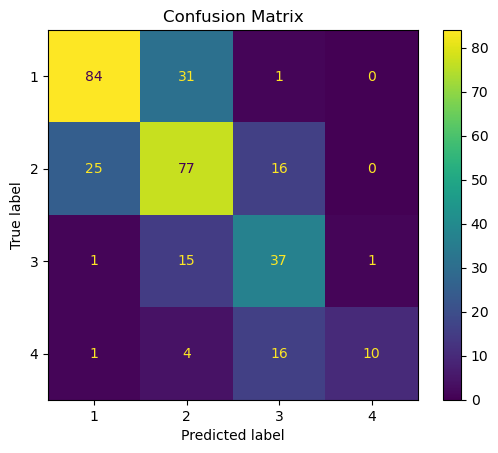

In [ ]:
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                              display_labels=[1, 2, 3, 4])
disp.plot(cmap="viridis", values_format="d")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

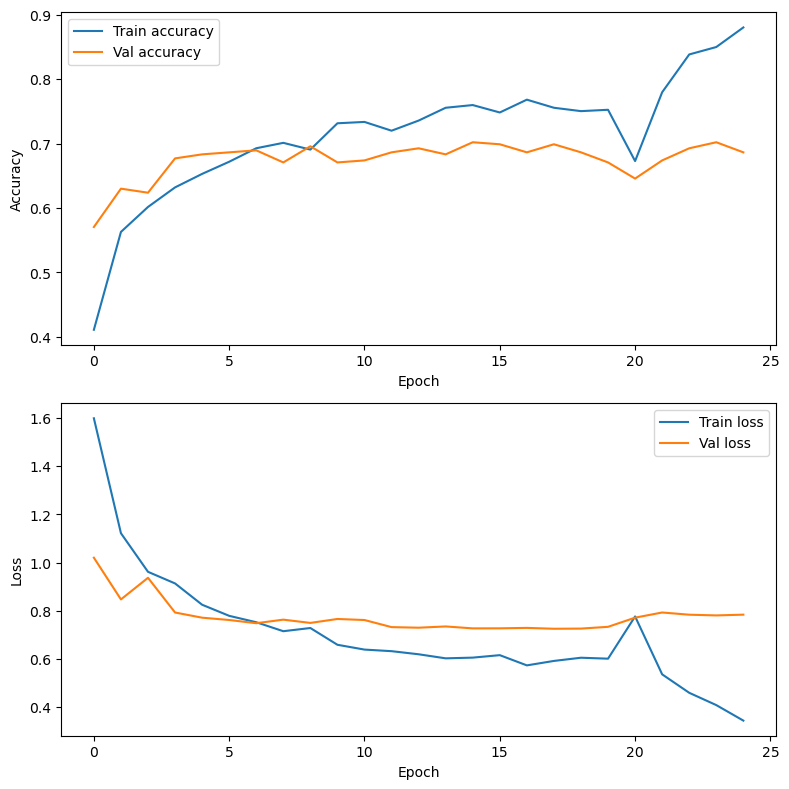

In [ ]:
epoch_summary = {k: r1.history[k] + (r2.history.get(k) or []) for k in r1.history}

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epoch_summary["accuracy"], label="Train accuracy")
plt.plot(epoch_summary["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epoch_summary["loss"], label="Train loss")
plt.plot(epoch_summary["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Discussion

The overall performance of the models compared are shown below:

| Model          | Dataset     | Accuracy | F1-score | MAE    |
| :------------- | :---------- | :------: | :------: | :----: |
| Random Forest  | Original    | 0.63     | 0.57     | 0.4035 |
| Random Forest  | Masked      | 0.61     | 0.56     | 0.4364 |
| Random Forest  | Soft-masked | 0.62     | 0.56     | 0.4396 |
| SVM            | Original    | 0.64     | 0.63     | 0.4160 |
| SVM            | Masked      | 0.59     | 0.58     | 0.4741 |
| SVM            | Soft-masked | 0.63     | 0.63     | 0.4019 |
| MobileNetV2    | Soft-masked | 0.66     | 0.60     | 0.3793 |
| EfficientNetB0 | Soft-masked | **0.67**     | **0.67**     | **0.3574** |
| ResNet50       | Soft-masked | 0.65     | 0.61     | 0.3730 |

Since SVM classifier with soft-masked images works the best among the machine learning methods, it was considered as a baseline to be compared with transfer learning methods. It also suggested that the soft-masked dataset should be chosen for better performance. The transfer learning methods generally resulted in higher accuracies, F1-scores, and lower MAEs, but the difference in accuracy and F1-score was not significant. The main reason could be the relatively small dataset in terms of CNNs. Nevertheless, EfficientNetB0 achieved the best performance with accuracy of 0.67 and F1-score of 0.67. Despite of the overall low accuracy in classification, the relatively low MAE of 0.3574 showed that most misclassifications were only off by a difference of 1 in risk level (e.g. classifying a level 2 risk into level 1 or 3). Since risk level is naturally ordinal, misclassifying a label with a difference of 1 does not hurt as much as one with greater difference.

Moreover, overestimating the risk level by the mocel is less concerned than underestimating it because of safety consideration. Although not shown in the table above, the confusion matrix in every result clearly displayed that underestimations occur when predicted value is less than the true value (the lower traingular region in the confusion matrix, below the diagonal), and overestimations occur otherwise. Therefore, the number of overestimation and underestimation could also be an important factor to evaluate the model performance.

## Limitation and Future Work

While the current study establishes a solid framework for automated risk assessment, several constraints were identified that provide a clear roadmap for future iterations.

### Current Limitations

The primary challenges encountered during this phase were centered on data quality and computational constraints. The relatively small size of the dataset, combined with the presence of nearly-identical images and potential human labeling errors, creates a risk of bias and limits the model's ability to generalize across all driving scenarios. Additionally, insufficient computing power acted as a bottleneck, restricting the complexity of the models and the speed of the training iterations.

### Future Directions

To address these challenges and enhance the system's robustness, future research will focus on the following key areas:

- Temporal and Contextual Modeling: Developing models that move beyond static images to account for the temporal evolution of a road scene, including frame-to-frame changes and variations between day and night.

- Ordinal Classification: Refining the risk assessment by treating risk levels as numerical values rather than independent categories, which better reflects the progressive nature of driving hazards.

- Improved Generalization: Expanding the scope to include data from different vehicle types and camera viewpoints to ensure the model's performance remains consistent across diverse hardware setups.

- Enhanced Environmental Awareness: Incorporating road geometry and lane detection to provide the model with a better "understanding" of the physical driving environment.

- Robust Ground Truths: Implementing cross-validated labeling processes to reduce subjectivity and ensure a more objective, high-accuracy training set.